In [ ]:
# I'm applying all my practical knowledge on this

## Data-Driven Insights from Global Happiness Index

# 🌍 World Happiness Report Analysis
### This project analyzes the World Happiness Report data to explore factors influencing global happiness using Python, statistics, and data visualization tools.


In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from bokeh.plotting import figure,output_file,show
from bokeh.sampledata.iris import flowers

In [145]:
list_of_dataset = ["2015.csv","2016.csv","2017.csv","2018.csv"]
def loaddatset(list_of_dataset):
    return [pd.read_csv(i) for i in list_of_dataset]

In [146]:
data = loaddatset(list_of_dataset)

In [147]:
data_2015 = data[0]
data_2016 = data[1]
data_2017  = data[2]
data_2018 = data[3]

In [148]:
data_2015.head(2)

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201


In [149]:
data_2015.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 1

In [150]:
data_2015.isnull().any().sum()

0

In [151]:
# Function to check null at different csv
check_null = []

for i,df in enumerate(data):
    null_count = df.isnull().sum().sum()
    check_null.append(f"Null data of {list_of_dataset[i]} is {null_count}")

In [152]:
check_null

['Null data of 2015.csv is 0',
 'Null data of 2016.csv is 0',
 'Null data of 2017.csv is 0',
 'Null data of 2018.csv is 1']

In [153]:
data_2018.isnull().any()

Overall rank                    False
Country or region               False
Score                           False
GDP per capita                  False
Social support                  False
Healthy life expectancy         False
Freedom to make life choices    False
Generosity                      False
Perceptions of corruption        True
dtype: bool

In [129]:
data_2018.shape

(156, 9)

In [110]:
data_2018[data_2018.isnull().any(axis=1)]

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption


In [57]:
# Handle Misssing Value
# We done Data Imputation

In [80]:
data_2018["Perceptions of corruption"].mean()

0.112

In [82]:
data_2018["Perceptions of corruption"].fillna(data4_2018["Perceptions of corruption"].mean(),inplace=True)

C:\Users\vishn\AppData\Local\Temp\ipykernel_12036\1957023051.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_2018["Perceptions of corruption"].fillna(data4_2018["Perceptions of corruption"].mean(),inplace=True)


In [154]:
data_2018.isnull().any()

Overall rank                    False
Country or region               False
Score                           False
GDP per capita                  False
Social support                  False
Healthy life expectancy         False
Freedom to make life choices    False
Generosity                      False
Perceptions of corruption        True
dtype: bool

In [155]:
# list of Index in each csv see at one place get understanding
list_cf  = []
for i in data:
    list_cf.append(i.columns)

In [199]:
list_cf

[Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
        'Standard Error', 'Economy (GDP per Capita)', 'Family',
        'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
        'Generosity', 'Dystopia Residual'],
       dtype='object'),
 Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
        'Lower Confidence Interval', 'Upper Confidence Interval',
        'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)',
        'Freedom', 'Trust (Government Corruption)', 'Generosity',
        'Dystopia Residual'],
       dtype='object'),
 Index(['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high',
        'Whisker.low', 'Economy..GDP.per.Capita.', 'Family',
        'Health..Life.Expectancy.', 'Freedom', 'Generosity',
        'Trust..Government.Corruption.', 'Dystopia.Residual'],
       dtype='object'),
 Index(['Overall rank', 'Country or region', 'Score', 'GDP per capita',
        'Social support', 'Healthy life exp

In [200]:
# We're changing it because it will be easy to fetch data and also in the scenario we need this data or column
# Happiness.Score is wrong in all csv so we will replace it 
data_2015.rename(columns={'Happiness Score': 'Happiness_Score'}, inplace=True)
data_2016.rename(columns={'Happiness Score': 'Happiness_Score'}, inplace=True)
data_2017.rename(columns={'Happiness.Score': 'Happiness_Score'}, inplace=True)
data_2018.rename(columns={'Score': 'Happiness_Score'}, inplace=True)

In [201]:
# Economy gdp is very like column name is very different so that also we need to change
data_2015.rename(columns={'Economy (GDP per Capita)': 'Economy (GDP per Capita)'}, inplace=True)
data_2016.rename(columns={'Economy (GDP per Capita)': 'Economy (GDP per Capita)'}, inplace=True)
data_2017.rename(columns={'Economy..GDP.per.Capita.': 'Economy (GDP per Capita)'}, inplace=True)
data_2018.rename(columns={'GDP per capita': 'Economy (GDP per Capita)'}, inplace=True)

In [202]:
data_2015.head(1)

,Country,Region,Happiness Rank,Happiness_Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,Predicted Score
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,6.596586


In [203]:
data_2016.head(1)

,Country,Region,Happiness Rank,Happiness_Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,Predicted Score
0,Denmark,Western Europe,1,7.526,7.46,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939,6.449156


In [204]:
data_2017.head(1)

,Country,Happiness.Rank,Happiness_Score,Whisker.high,Whisker.low,Economy (GDP per Capita),Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027


In [205]:
data_2018.rename(columns={"Country or region": "Country"},inplace=True)
data_2018.head(1)

,Overall rank,Country,Happiness_Score,Economy (GDP per Capita),Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393


In [140]:
## i CAN USE OOPS
class Dataset:
    def __init__(self, file_path):
        self.df = pd.read_csv(file_path)

    def show_nulls(self):
        return self.df.isnull().sum()

    def fill_missing(self, column):
        mean_val = self.df[column].mean()
        self.df[column] = self.df[column].fillna(mean_val)

In [141]:
data_2018 = Dataset("2018.csv")
data_2018.show_nulls()
data_2018.fill_missing("Perceptions of corruption")

In [142]:
data_2018

In [143]:
class NullFiller:
    def __init__(self, strategy='mean'):
        self.strategy = strategy

    def fit_transform(self, df, column):
        if self.strategy == 'mean':
            value = df[column].mean()
        elif self.strategy == 'median':
            value = df[column].median()
        df[column] = df[column].fillna(value)
        return df


In [ ]:
## Use NULLFILLER
filler = NullFiller(strategy='mean')
df = filler.fit_transform(df, 'score')
print(df)

In [175]:
data_2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        155 non-null    object 
 1   Happiness.Rank                 155 non-null    int64  
 2   Happiness.Score                155 non-null    float64
 3   Whisker.high                   155 non-null    float64
 4   Whisker.low                    155 non-null    float64
 5   Economy..GDP.per.Capita.       155 non-null    float64
 6   Family                         155 non-null    float64
 7   Health..Life.Expectancy.       155 non-null    float64
 8   Freedom                        155 non-null    float64
 9   Generosity                     155 non-null    float64
 10  Trust..Government.Corruption.  155 non-null    float64
 11  Dystopia.Residual              155 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 

In [178]:
corr = data_2016[['Economy (GDP per Capita)', 'Happiness Score']].corr()

In [174]:
data_2015[['Economy (GDP per Capita)', 'Happiness Score']].corr()

,Economy (GDP per Capita),Happiness Score
Economy (GDP per Capita),1.000000,0.780966
Happiness Score,0.780966,1.000000


In [176]:
data_2017[['Economy..GDP.per.Capita.', 'Happiness.Score']].corr()

,Economy..GDP.per.Capita.,Happiness.Score
Economy..GDP.per.Capita.,1.000000,0.812469
Happiness.Score,0.812469,1.000000


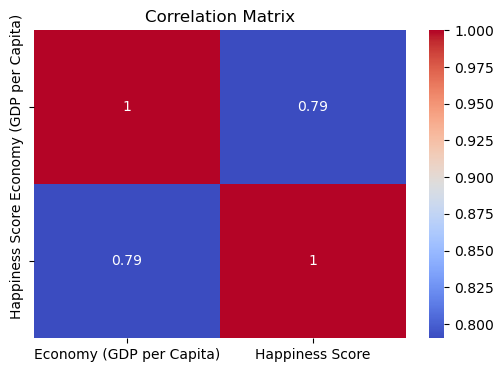

In [192]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [182]:
data_2015.head(1)

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738


In [189]:
data_2015.columns

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Standard Error', 'Economy (GDP per Capita)', 'Family',
       'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
       'Generosity', 'Dystopia Residual'],
      dtype='object')

# "Is there a relationship between GDP per Capita and Happiness Score across countries in 2015? Can we visualize it and interpret the trend?"

In [198]:
data_2017.columns

Index(['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high',
       'Whisker.low', 'Economy..GDP.per.Capita.', 'Family',
       'Health..Life.Expectancy.', 'Freedom', 'Generosity',
       'Trust..Government.Corruption.', 'Dystopia.Residual'],
      dtype='object')

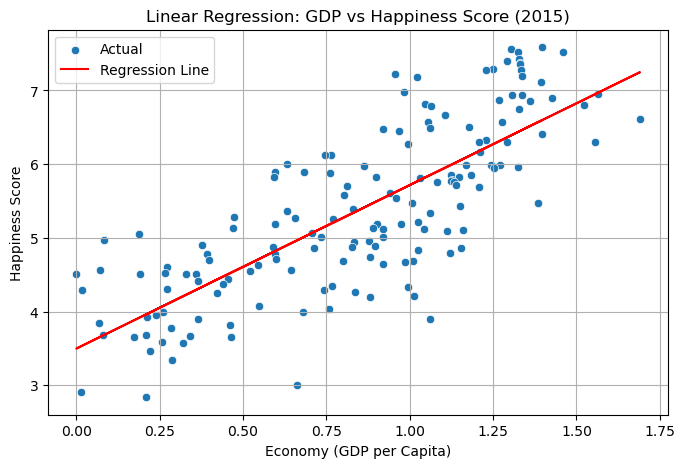

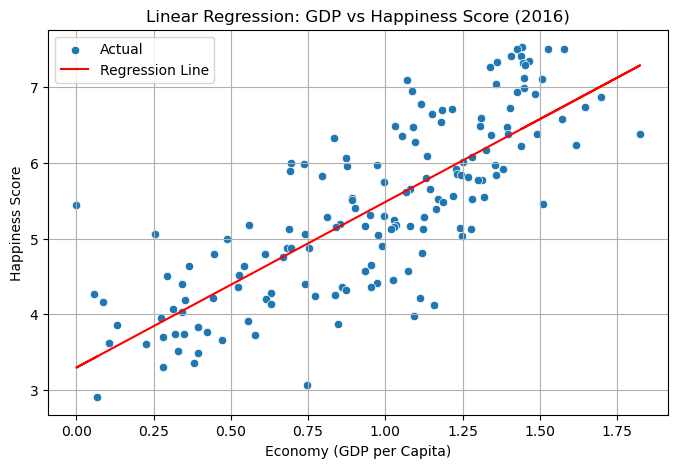

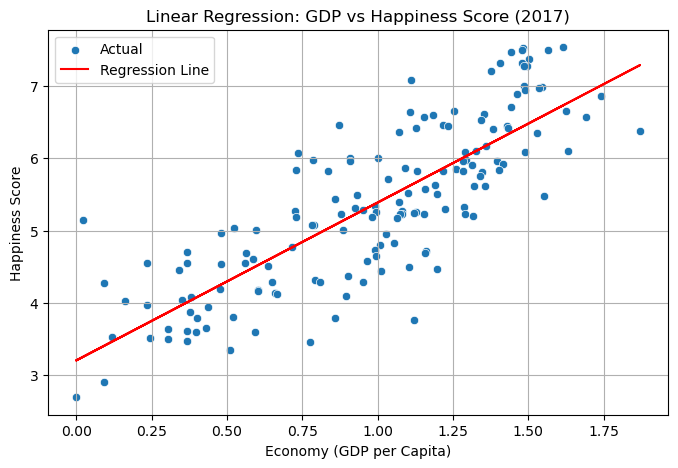

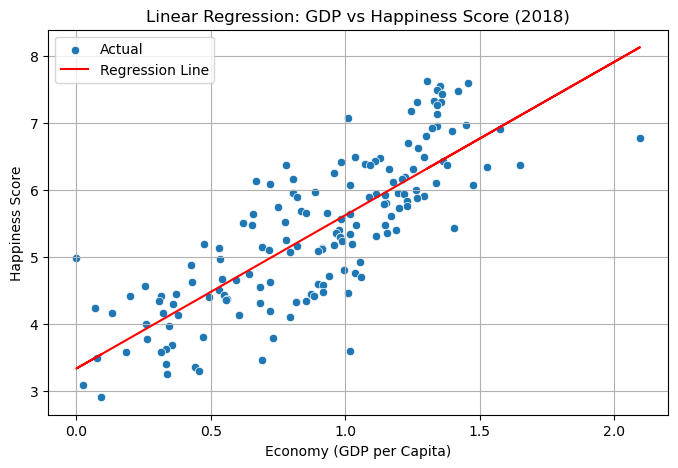

In [208]:
datasets = {
    '2015': data_2015,
    '2016': data_2016,
    '2017': data_2017,
    '2018': data_2018
}

from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

for year, df in datasets.items():
    # Prepare data
    X = df[['Economy (GDP per Capita)']]
    y = df['Happiness_Score']

    # Fit model
    model = LinearRegression()
    model.fit(X, y)

    # Predict and store results in the same DataFrame
    df['Predicted Score'] = model.predict(X)

    # Plot
    plt.figure(figsize=(8,5))
    sns.scatterplot(x='Economy (GDP per Capita)', y='Happiness_Score', data=df, label='Actual')
    plt.plot(df['Economy (GDP per Capita)'], df['Predicted Score'], color='red', label='Regression Line')
    plt.title(f"Linear Regression: GDP vs Happiness Score ({year})")
    plt.xlabel("Economy (GDP per Capita)")
    plt.ylabel("Happiness Score")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"gdp_vs_happiness_{year}.png", dpi=300, bbox_inches='tight')
    plt.show()
